## Ajuste de perspectiva na prática  

Nosso objetivos será construir **dois pipelines**:

1) **Scanner** (retificação) usando **4 pontos** + `getPerspectiveTransform` + `warpPerspective`  
2) **Homografia automática** com **features + matching + RANSAC** usando `findHomography` + `warpPerspective`

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, title=None, size=6, cmap=None):
    """Mostra imagem com matplotlib (converte BGR->RGB automaticamente quando necessário)."""
    plt.figure(figsize=(size, size))
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap or 'gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

print('OpenCV:', cv2.__version__)

OpenCV: 4.9.0


## Parte A - Scanner por 4 pontos (retificação)

A ideia: escolher 4 pontos na imagem (cantos do papel/quadro) e mapear para um retângulo “reto”.  
Isso usa **transformação projetiva** (homografia) calculada por **4 correspondências**.

- `getPerspectiveTransform(src4, dst4)` → calcula matriz 3×3  
- `warpPerspective(img, M, (W, H))` → aplica o warp

> **Dica:** O maior erro é **ordem dos pontos**. Vamos resolver isso com uma função `order_points`.


In [2]:
def order_points(pts):
    """Ordena 4 pontos no formato: topo-esq, topo-dir, baixo-dir, baixo-esq."""
    pts = np.array(pts, dtype=np.float32) 
    s = pts.sum(axis=1) 
    diff = np.diff(pts, axis=1).reshape(-1) 

    tl = pts[np.argmin(s)]
    br = pts[np.argmax(s)]
    tr = pts[np.argmin(diff)]
    bl = pts[np.argmax(diff)]
    return np.array([tl, tr, br, bl], dtype=np.float32)

def four_point_warp(image_bgr, pts4):
    """Retifica a região definida por 4 pontos (em qualquer ordem)."""
    rect = order_points(pts4)
    (tl, tr, br, bl) = rect

    # Calcula largura do retângulo destino
    widthA = np.linalg.norm(br - bl) # distância entre baixo-dir e baixo-esq
    widthB = np.linalg.norm(tr - tl) # distância entre topo-dir e topo-esq
    maxW = int(max(widthA, widthB)) # largura do retângulo destino

    # Calcula altura do retângulo destino
    heightA = np.linalg.norm(tr - br) # distância entre topo-dir e baixo-dir
    heightB = np.linalg.norm(tl - bl) # distância entre topo-esq e baixo-esq
    maxH = int(max(heightA, heightB)) # altura do retângulo destino

    dst = np.array([ 
        [0, 0],                 # topo-esq
        [maxW - 1, 0],          # topo-dir
        [maxW - 1, maxH - 1],   # baixo-dir
        [0, maxH - 1]           # baixo-esq
    ], dtype=np.float32)        

    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image_bgr, M, (maxW, maxH))
    return warped, M, rect, dst

## A1) Carregar uma imagem (documento/quadro)

Se preferir, troque o caminho abaixo.


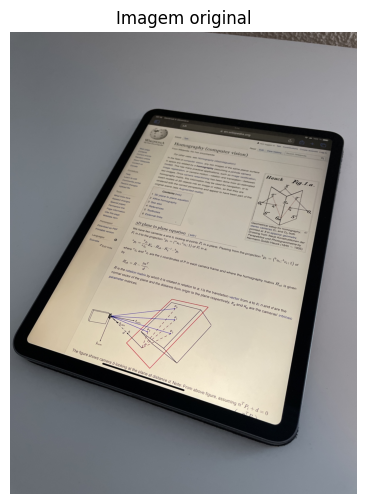

In [3]:
img_path = 'lab_images/image.png'
img = cv2.imread(img_path)

show(img, 'Imagem original')

## A2) Seleção manual de 4 pontos (mouse)

Você vai clicar nos 4 cantos do documento/quadro.  

**Como usar:**

- Clique 4 pontos
- Pressione `ENTER` para finalizar
- Pressione `R` para resetar
- Pressione `ESC` para sair (sem salvar pontos)

> **Obs.:** esta parte abre uma janela do OpenCV. Se estiver em ambiente que não abre janela, pule para A3 (pontos hard-coded).


In [5]:
def pick_four_points(image_bgr, window_name='Selecione 4 pontos (ENTER confirma, R reseta)'):
    pts = []
    clone = image_bgr.copy()

    def mouse_cb(event, x, y, flags, param):
        nonlocal pts, clone
        if event == cv2.EVENT_LBUTTONDOWN:
            pts.append((x, y))
            cv2.circle(clone, (x, y), 6, (0, 255, 0), -1)
            cv2.putText(clone, str(len(pts)), (x+8, y-8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    cv2.namedWindow(window_name)
    cv2.setMouseCallback(window_name, mouse_cb)

    while True:
        cv2.imshow(window_name, clone)
        key = cv2.waitKey(1) & 0xFF

        if key == 27:  # ESC
            pts = []
            break
        if key == ord('r'):
            pts = []
            clone = image_bgr.copy()
        if key == 13:  # ENTER
            break
        if len(pts) == 4:
            pass
            # break

    cv2.destroyWindow(window_name)
    return pts

if img is not None:
    pts4 = pick_four_points(img)
    print('Pontos selecionados:', pts4)

Pontos selecionados: [(600, 648), (758, 681), (709, 807), (536, 773)]


## A3) Retificar com 4 pontos

Se você não conseguiu usar a seleção manual (por limitação de ambiente), você pode definir `pts4` manualmente (x,y).

Exemplo:
```python
pts4 = [(120, 90), (540, 110), (600, 820), (80, 800)]
```


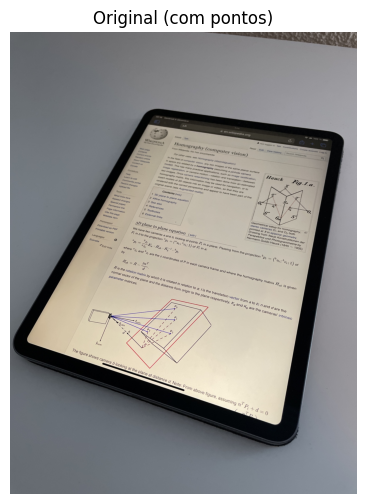

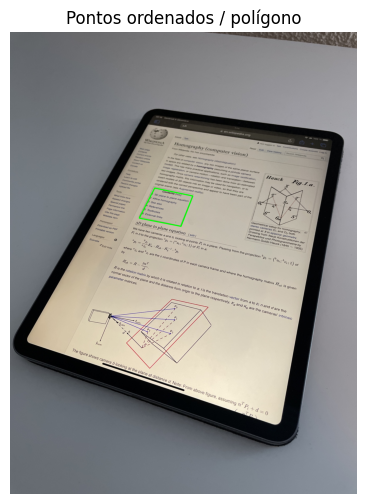

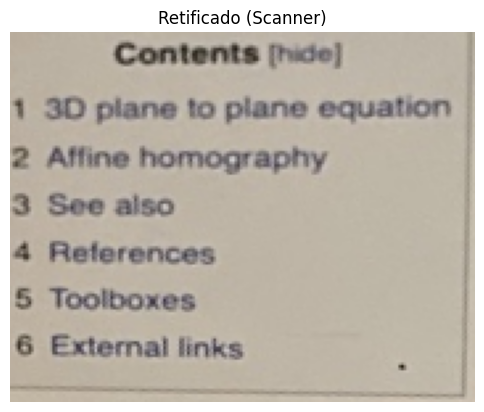

In [6]:
# realiza a transformação de perspectiva (retificação)
warped, M, rect, dst = four_point_warp(img, pts4)
show(img, 'Original (com pontos)')

# desenha polígono
vis = img.copy()
poly = rect.astype(int).reshape(-1, 1, 2) # formato necessário para cv2.polylines
cv2.polylines(vis, [poly], True, (0, 255, 0), 3) # polígono verde
show(vis, 'Pontos ordenados / polígono')

# mostra resultado
show(warped, 'Retificado (Scanner)')

### Desafio — Qualidade de retificação

1) Teste com outro documento/quadro (ou outra foto)  

2) Compare retificação com pontos bem escolhidos vs pontos “meio errados” 


# Parte B — Scanner automático por contorno (opcional, mas recomendado)

Ideia:
- imagem em escala de cinza → filtro blur → bordas com Canny → encontra contornos → pega o maior contorno → aproximação poligonal  
- se o contorno aproximado tiver 4 vértices, usamos como cantos.

> Isso funciona melhor com documentos bem destacados do fundo.


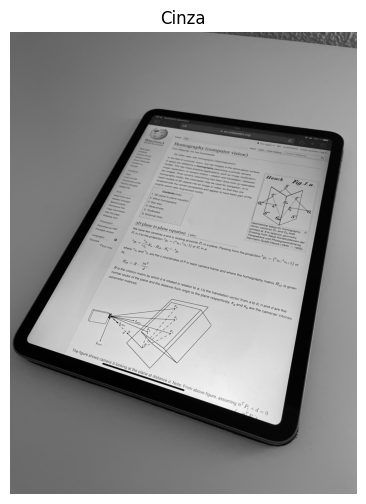

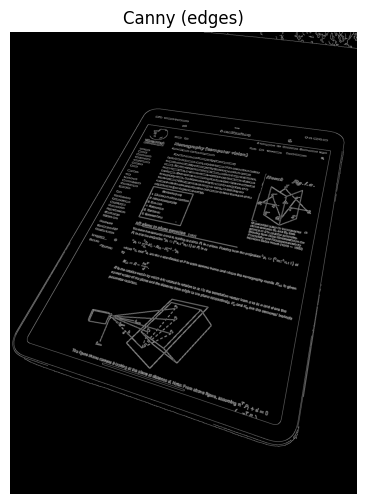

Cantos encontrados: [[574.0, 384.0], [72.0, 1285.0], [1112.0, 1629.0], [1330.0, 494.0]]


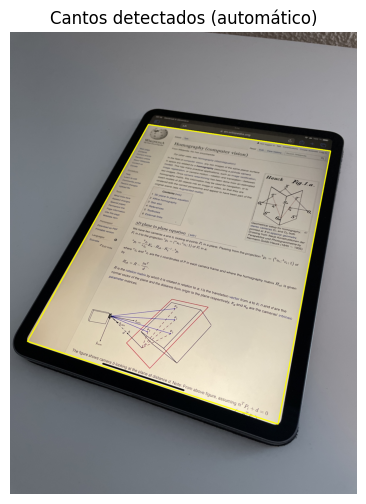

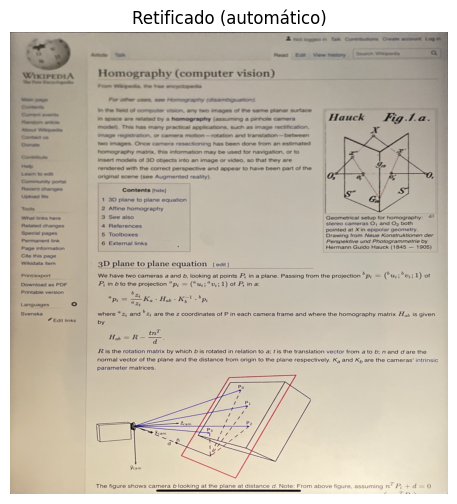

In [11]:
def find_document_corners(image_bgr):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (3, 3), 0)
    edges = cv2.Canny(blur, 50, 150)

    cnts, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = sorted(cnts, key=cv2.contourArea, reverse=True) # ordena por área (maior primeiro)

    for c in cnts[:10]:
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * peri, True)
        if len(approx) == 4:
            pts = approx.reshape(4, 2).astype(np.float32)
            return pts, edges, gray
    return None, edges, gray


corners, edges, gray = find_document_corners(img)
show(gray, 'Cinza')
show(edges, 'Canny (edges)')

if corners is not  None:
    print('Cantos encontrados:', corners.tolist())
    vis = img.copy()
    cv2.polylines(vis, [corners.astype(int).reshape(-1,1,2)], True, (0, 255, 255), 3)
    show(vis, 'Cantos detectados (automático)')
    warped2, M2, rect2, dst2 = four_point_warp(img, corners)
    show(warped2, 'Retificado (automático)')
else:
    print('Não foram encontrados cantos do documento.')

### Desafio 2 — Robustez do contorno

- Ajuste os parâmetros do Canny (50,150) e do `approxPolyDP` (0.02) 

- Teste um caso difícil (imagem com fundo poluído, sombra, reflexo).


# Parte C — Homografia automática por matching + RANSAC

Agora você vai alinhar duas imagens de uma **mesma cena plana** (ex.: pôster, capa de livro, quadro, folha) usando:

1) ORB (ou SIFT se disponível)  
2) matching (BFMatcher)  
3) filtro (ratio test)  
4) `findHomography(..., RANSAC)`  
5) `warpPerspective`

> A maior diferença aqui é lidar com **outliers**. Por isso usamos RANSAC.


## C1) Carregar duas imagens para alinhar

- Exemplo bom: duas fotos do mesmo pôster na parede, com perspectiva diferente.


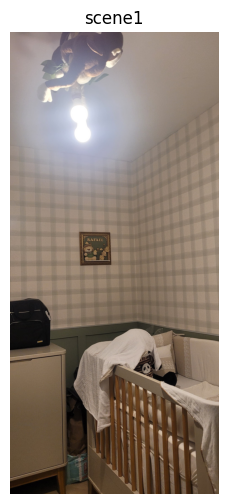

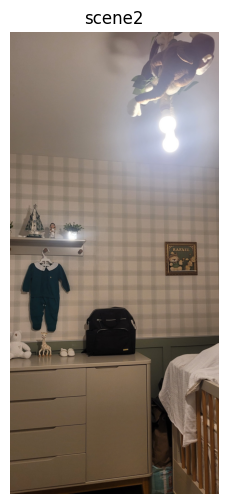

In [12]:
img1_path = 'lab_images/quarto.jpeg'
img2_path = 'lab_images/quarto1.jpeg'

img1 = cv2.imread(img1_path)
img2 = cv2.imread(img2_path)

show(img1, 'scene1')
show(img2, 'scene2')

## C2) Detectar features e fazer matching (ORB)

Keypoints A: 2000 Keypoints B: 2000
Good matches: 499


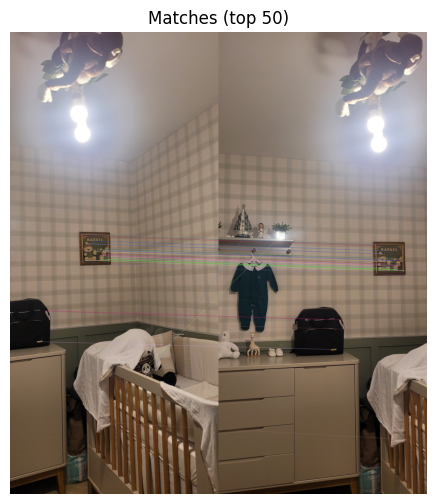

In [13]:
def orb_match(imgA, imgB, nfeatures=2000):
    orb = cv2.ORB_create(nfeatures=nfeatures)
    grayA = cv2.cvtColor(imgA, cv2.COLOR_BGR2GRAY)
    grayB = cv2.cvtColor(imgB, cv2.COLOR_BGR2GRAY)

    kpA, desA = orb.detectAndCompute(grayA, None)
    kpB, desB = orb.detectAndCompute(grayB, None)

    if desA is None or desB is None:
        return None

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    knn = bf.knnMatch(desA, desB, k=2)

    # Ratio test (Lowe) adaptado para ORB
    good = []
    for m, n in knn:
        if m.distance < 0.75 * n.distance:
            good.append(m)

    return kpA, kpB, good

# compara as duas cenas
res = orb_match(img1, img2)

# mostra resultados
kpA, kpB, good = res
print('Keypoints A:', len(kpA), 'Keypoints B:', len(kpB))
print('Good matches:', len(good))

vis = cv2.drawMatches(img1, kpA, img2, kpB, good[:50], None,
                            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
show(vis, 'Matches (top 50)')

## C3) Estimar homografia com RANSAC + aplicar warp

Vamos estimar H que mapeia `img1 → img2`.
- `srcPts`: pontos em `img1`
- `dstPts`: pontos correspondentes em `img2`

A função retorna também `mask_inliers` indicando quais matches foram aceitos.


H:
 [[ 8.42948659e-01 -8.06166258e-03  7.81230987e+02]
 [-1.63956419e-01  9.50196169e-01  1.76663796e+02]
 [-8.27959673e-05 -1.34882567e-06  1.00000000e+00]]
Inliers: 411/499 (82.4%)


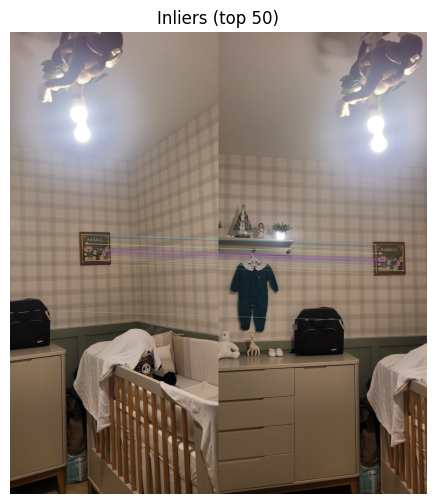

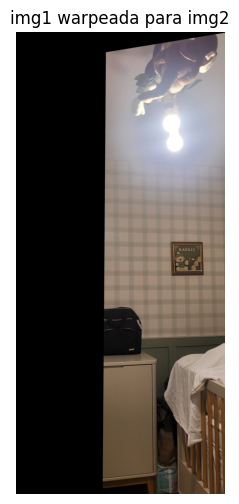

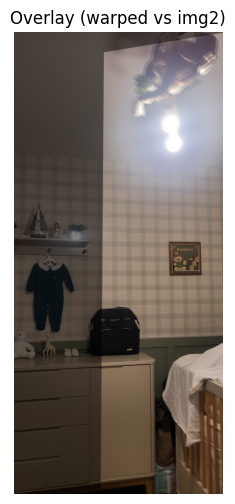

In [14]:
def homography_from_matches(kpA, kpB, matches, ransac_thresh=5.0):
    if len(matches) < 8:
        return None

    srcPts = np.float32([kpA[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    dstPts = np.float32([kpB[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(srcPts, dstPts, cv2.RANSAC, ransac_thresh)
    return H, mask, srcPts, dstPts

if img1 is not None and img2 is not None and 'res' in globals() and res is not None:
    H_res = homography_from_matches(kpA, kpB, good, ransac_thresh=13.0)
    if H_res is None:
        print('Poucos matches para homografia.')
    else:
        H, mask, srcPts, dstPts = H_res
        inliers = int(mask.sum())
        total = len(mask)
        print('H:\n', H)
        print(f'Inliers: {inliers}/{total} ({inliers/total:.1%})')

        # Desenha apenas inliers
        inlier_matches = [m for m, keep in zip(good, mask.ravel()) if keep]
        vis_in = cv2.drawMatches(img1, kpA, img2, kpB, inlier_matches[:50], None,
                                 flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
        show(vis_in, 'Inliers (top 50)')

        # Warp img1 para o referencial de img2
        h2, w2 = img2.shape[:2]
        warped = cv2.warpPerspective(img1, H, (w2, h2))
        show(warped, 'img1 warpeada para img2')
        # Visualização simples: diferença / overlay
        overlay = cv2.addWeighted(warped, 0.5, img2, 0.5, 0)
        show(overlay, 'Overlay (warped vs img2)')

### Desafio C — Ajuste de parâmetros (ganha robustez)

1) Varie `ransac_thresh` (ex.: 3.0, 5.0, 8.0) e compare inliers e alinhamento.  
2) Varie o ratio test (0.70, 0.75, 0.80) e compare.

Pergunta: **o que acontece quando você “afrouxa” demais?**


# Parte D — com SIFT


SIFT keypoints: 8401 6152 good: 1206
SIFT Inliers: 678/1206 (56.2%)


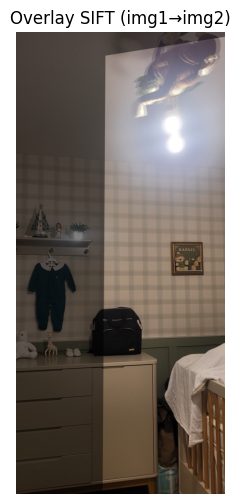

: 

In [ ]:
def sift_match(imgA, imgB):
    sift = cv2.SIFT_create()
    grayA = cv2.cvtColor(imgA, cv2.COLOR_BGR2GRAY)
    grayB = cv2.cvtColor(imgB, cv2.COLOR_BGR2GRAY)

    kpA, desA = sift.detectAndCompute(grayA, None)
    kpB, desB = sift.detectAndCompute(grayB, None)

    if desA is None or desB is None:
        return None

    # FLANN para SIFT (float descriptors)
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    knn = flann.knnMatch(desA, desB, k=2)

    good = []
    for m, n in knn:
        if m.distance < 0.75 * n.distance:
            good.append(m)

    return kpA, kpB, good

# compara as duas cenas usando SIFT
res_s = sift_match(img1, img2)
if res_s is None:
    print('Falha com SIFT.')
else:
    kpAs, kpBs, goods = res_s
    print('SIFT keypoints:', len(kpAs), len(kpBs), 'good:', len(goods))

    Hs_res = homography_from_matches(kpAs, kpBs, goods, ransac_thresh=3.0)
    if Hs_res is None:
        print('Poucos matches para homografia SIFT.')
    else:
        Hs, masks, *_ = Hs_res
        inl = int(masks.sum()); tot = len(masks)
        print(f'SIFT Inliers: {inl}/{tot} ({inl/tot:.1%})')
        warped_s = cv2.warpPerspective(img1, Hs, (img2.shape[1], img2.shape[0]))
        overlay_s = cv2.addWeighted(warped_s, 0.5, img2, 0.5, 0)
        show(overlay_s, 'Overlay SIFT (img1→img2)')